In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import math
from scipy.stats import boxcox, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import f_classif
import scipy.stats as stats
import statistics
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

In [48]:
observation = pd.read_csv('../../observation.csv', delimiter='\t')
patient = pd.read_csv('../../patient.csv', delimiter='\t')
station = pd.read_csv('../../station.csv', delimiter='\t')
patient = patient.drop("residence", axis=1)
patient = patient.drop('birthdate', axis=1)
patient = patient.drop("job", axis=1)
merged = pd.merge(
    patient, 
    station, 
    left_on='station_ID',
    right_index=True
)
observation_copy = observation.copy()

# **2.1 Realizácia predspracovania dát (5b)**

# A-1b

In [49]:
patient['user_id'] = patient['user_id'].astype('int64')
patient['station_ID'] = patient['station_ID'].astype('int64')
patient['blood_group'] = patient['blood_group'].astype('category')
cols = ['username', 'company', 'job', 'mail', 'name', 'ssn']
for col in cols:
        if col in patient.columns:
            patient[col] = patient[col].astype('string')

In [50]:
station['code'] = station['code'].astype('string')
station['station'] = station['station'].astype('string')
station['location'] = station['location'].astype('string')

In [51]:
patient.head()

,user_id,current_location,username,company,registration,mail,name,ssn,blood_group,station_ID
0,1544,"(Decimal('-67.5402955'), Decimal('-114.522482'))",ucolletti,Corcos SPA,25 May 2025,francesco60@gmail.com,Giorgia Sauro,SRNFST50B52F775U,O+,428
1,4,"(Decimal('24.680131'), Decimal('32.809946'))",sayurikobayashi,株式会社藤井建設,07 Jul 2025,vmiura@hotmail.com,佐々木 学,481-65-6983,O-,451
2,1501,"(Decimal('-51.1234865'), Decimal('130.651957'))",nbenthin,Rogner Wilms GmbH & Co. KG,"10/25/2021, 00:00:00",ajungfer@gmx.de,Evelin Fischer,566-56-2746,O-,204
3,653,"(Decimal('-60.9439985'), Decimal('157.720074'))",ndias,Ferreira,09 Jun 2020,maria-luisacarvalho@uol.com.br,Davi Lucca Guerra,65940318215,B-,82
4,1116,"(Decimal('46.6915195'), Decimal('-51.672004'))",montesanolivio,Andreozzi s.r.l.,2023/07/23,lucianapacomio@tiscali.it,Venancio Morgagni,CNTSMN15B57G939D,O+,173


In [52]:
station.head()

,code,latitude,location,longitude,station,revision
0,US,40.93121,America/New_York,-73.89875,Yonkers,2021/01/24
1,IN,27.92470,Asia/Kolkata,78.40102,Chharra,2022/03/25
2,US,33.03699,America/Los_Angeles,-117.29198,Encinitas,"07/02/2023, 00:00:00"
3,FR,48.98994,Europe/Paris,2.16990,Herblay,"08/24/2018, 00:00:00"
4,DE,50.72043,Europe/Berlin,11.34046,Rudolstadt,2023-01-28


In [53]:
observation.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.240653,81.353362,7.150900,16.455165,40.139514,58.088019,130.517598,106.734767,34.575495,6.744899,...,4.109261,61.972714,31.751870,53.023017,54.786281,0.264564,32.364555,0.0,51.84819,1.26738
1,98.296387,69.297622,9.748389,18.179820,40.202706,59.981954,92.571343,94.833525,34.402921,12.358720,...,4.011034,53.873430,53.549948,59.871862,44.600096,0.298243,21.470525,1.0,19.32932,-98.16640
2,97.561590,84.103847,12.457043,14.090045,40.163760,57.037165,82.981147,109.770957,36.362083,13.112131,...,4.196129,44.945105,68.897858,64.007301,31.875287,0.208295,35.141216,1.0,34.21639,-119.03760
3,97.956431,69.736747,10.159555,16.073192,38.367245,60.461869,113.123181,103.350282,35.164909,5.395552,...,4.018147,25.615688,37.049185,55.797946,54.223522,0.219717,22.754344,0.0,43.61058,1.33467
4,98.641145,83.580193,12.462217,13.957125,40.933822,54.375525,122.740320,104.684783,33.884270,3.844221,...,4.183259,21.927280,58.039403,48.895308,55.838077,0.296221,27.145677,0.0,11.85000,38.01667


In [54]:
observation.describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,...,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000
mean,97.612862,80.687149,9.180268,16.342317,40.090329,59.414828,106.602260,104.550611,35.694128,9.731759,...,4.165612,45.165750,48.463326,53.154081,49.478761,0.249502,29.976833,0.595325,28.733944,10.275859
std,0.697656,5.157388,2.372628,0.969665,1.257749,10.810266,24.538449,3.716866,0.924738,3.104441,...,0.205145,12.709840,12.606927,13.383947,13.846784,0.028928,5.758020,0.490849,24.035512,74.548317
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,0.924405,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-44.396720,-156.474320
25%,97.113396,77.271022,7.591189,15.696061,39.244287,52.172970,90.115714,102.051752,34.929047,7.395671,...,4.057830,36.563536,39.973527,44.158125,39.937886,0.224488,24.978078,0.000000,14.537670,-60.183100
50%,97.660583,80.691323,9.169076,16.342201,40.068287,59.445967,106.294352,104.548336,35.859879,9.681788,...,4.104875,44.911991,48.335429,53.284007,49.486977,0.248999,30.041891,1.000000,36.063860,10.700000
75%,98.118804,84.143183,10.775421,16.982630,40.909909,66.643100,123.239900,107.058445,36.462289,12.342498,...,4.195550,53.716437,57.022272,62.167158,58.850744,0.274651,34.946009,1.000000,47.805270,70.911060
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,200.000000,120.000000,38.000000,18.152173,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,68.798330,178.004170


In [55]:
final_data = observation.copy()

In [56]:
def predspracovanie_train(X_train):
    Q1_bfi = X_train['Blood Flow Index'].quantile(0.25)
    Q3_bfi = X_train['Blood Flow Index'].quantile(0.75)
    IQR_bfi = Q3_bfi - Q1_bfi
    lower_bfi = Q1_bfi - 1.5 * IQR_bfi
    upper_bfi = Q3_bfi + 1.5 * IQR_bfi
    outliers_bfi = (X_train['Blood Flow Index'] < lower_bfi) | (X_train['Blood Flow Index'] > upper_bfi)
    outliers_bfi.sum()
    
    Q1_ppg = X_train['PPG waveform features'].quantile(0.25)
    Q3_ppg = X_train['PPG waveform features'].quantile(0.75)
    IQR_ppg = Q3_ppg - Q1_ppg
    lower_ppg = Q1_ppg - 1.5 * IQR_ppg
    upper_ppg = Q3_ppg + 1.5 * IQR_ppg
    outliers_ppg = (X_train['PPG waveform features'] < lower_ppg) | (X_train['PPG waveform features'] > upper_ppg)
    outliers_ppg.sum()
    
    Q1_sqi = X_train['Signal Quality Index'].quantile(0.25)
    Q3_sqi = X_train['Signal Quality Index'].quantile(0.75)
    IQR_sqi = Q3_sqi - Q1_sqi
    lower_sqi = Q1_sqi - 1.5 * IQR_sqi
    upper_sqi = Q3_sqi + 1.5 * IQR_sqi
    outliers_sqi = (X_train['Signal Quality Index'] < lower_sqi) | (X_train['Signal Quality Index'] > upper_sqi)
    outliers_sqi.sum()
    
    
    Q1_resp = X_train['Respiratory effort'].quantile(0.25)
    Q3_resp = X_train['Respiratory effort'].quantile(0.75)
    IQR_resp = Q3_resp - Q1_resp
    lower_resp = Q1_resp - 1.5 * IQR_resp
    upper_resp = Q3_resp + 1.5 * IQR_resp
    outliers_resp = (X_train['Respiratory effort'] < lower_resp) | (X_train['Respiratory effort'] > upper_resp)
    outliers_resp.sum()
    
    X_train = X_train[
        ~(
            outliers_bfi |
            outliers_ppg |
            outliers_sqi |
            outliers_resp
        )
    ]
    return X_train

In [57]:
final_data = predspracovanie_train(final_data)

In [58]:
train_data, test_data = train_test_split(
    final_data,
    test_size=0.25,
    random_state=42
)

test_data_backup = test_data.copy()
train_data_backup = train_data.copy()

In [59]:
target_column = 'oximetry'

X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]

print(f"Target Description:")
print(f" - name: {y_train.name}")
print(f" - data type: {y_train.dtype}")
desc = y_train.describe()
for stat, value in desc.items():
    print(f" - {stat}: {value:.2f}")

    
print(f"\nTraining data(features + target): {train_data.shape}")
print(f"Testing data(features + target): {test_data.shape}")

Target Description:
 - name: oximetry
 - data type: float64
 - count: 8766.00
 - mean: 0.60
 - std: 0.49
 - min: 0.00
 - 25%: 0.00
 - 50%: 1.00
 - 75%: 1.00
 - max: 1.00

Training data(features + target): (8766, 23)
Testing data(features + target): (2923, 23)


Data was transformed in training and testing datasets in a ratio of **75%** to **25%**. <br/>
**Oximetry** column was also highlighted as target column of our research.

# B-1b

In [60]:
X_train.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,SV,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude
8200,98.208748,80.323656,12.150147,15.283295,39.077906,69.498459,123.898105,102.350237,36.180164,7.387721,...,73.496548,4.103448,36.736880,36.489288,36.809471,60.852602,0.287768,28.862638,55.25000,24.75000
4552,97.380011,78.248592,10.250743,17.450963,41.571342,59.885806,69.517592,108.425766,36.275044,11.966966,...,77.138595,4.059704,38.683294,60.250658,49.979726,43.846962,0.271748,35.764563,-17.73648,168.31366
9412,96.995350,85.760481,8.998016,17.675217,38.004043,56.297085,119.491511,103.626067,35.430986,7.555965,...,70.452166,4.277675,28.686236,59.802226,77.230241,69.823809,0.246302,26.550661,41.55815,-73.05150
622,97.065277,90.041071,10.153855,17.136273,39.165934,60.082066,124.300843,111.593069,35.379090,7.152051,...,84.922665,4.591265,50.026568,44.697854,64.135994,72.256898,0.206866,23.740835,46.51872,86.00214
3930,98.553893,74.009752,9.151582,16.053110,39.920258,55.313066,106.625515,106.026883,34.127712,3.849298,...,90.539007,4.037799,35.791613,41.743906,69.190474,54.604334,0.267024,38.561122,56.85836,35.90057


In [61]:
X_train.shape

(8766, 22)

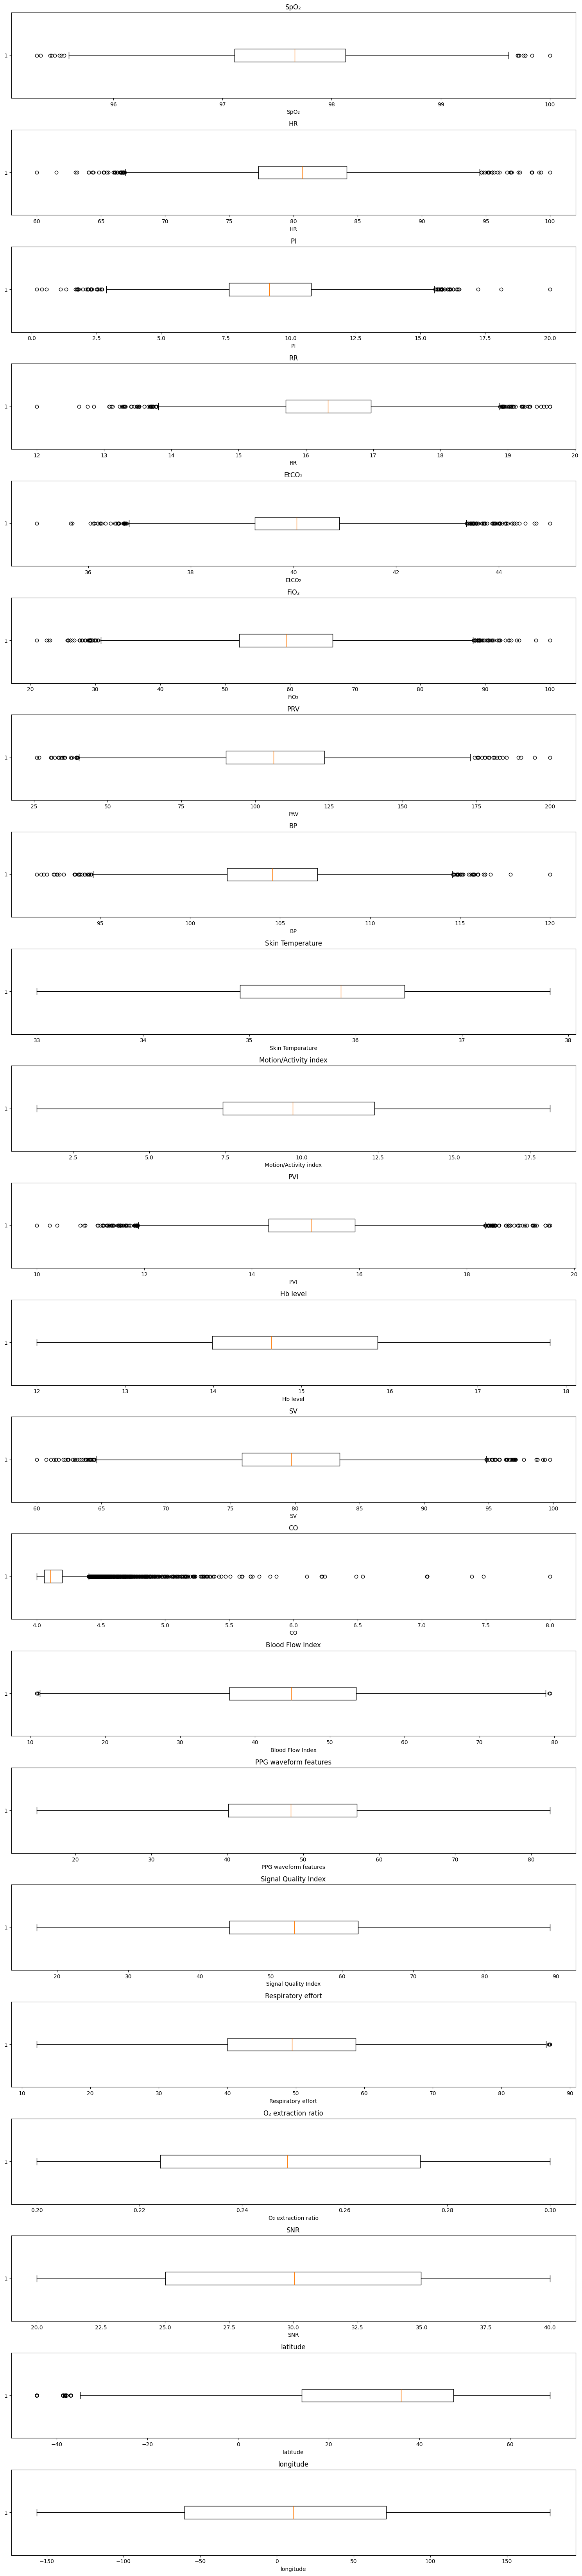

In [62]:
cols = X_train.columns

plt.figure(figsize=(15, len(cols) * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.boxplot(X_train[col].dropna(), vert=False)
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [63]:
print("Data Types:")
for col in train_data.columns:
    dtype = train_data[col].dtype
    print(f" - {col}: {dtype}")

Data Types:
 - SpO₂: float64
 - HR: float64
 - PI: float64
 - RR: float64
 - EtCO₂: float64
 - FiO₂: float64
 - PRV: float64
 - BP: float64
 - Skin Temperature: float64
 - Motion/Activity index: float64
 - PVI: float64
 - Hb level: float64
 - SV: float64
 - CO: float64
 - Blood Flow Index: float64
 - PPG waveform features: float64
 - Signal Quality Index: float64
 - Respiratory effort: float64
 - O₂ extraction ratio: float64
 - SNR: float64
 - oximetry: float64
 - latitude: float64
 - longitude: float64


As we can see all data is **float64** data type, which is the perfect format for machine learning. No string or categorial data found.

In [64]:
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Columns: {len(numeric_cols)} columns")
for col in numeric_cols:
    print(f" - {col}")

non_numeric_cols = train_data.select_dtypes(exclude=['int64', 'float64']).columns
print(f"Non-numerical Columns: {len(non_numeric_cols)} columns")
for col in non_numeric_cols:
    print(f" - {col}")

Numerical Columns: 23 columns
 - SpO₂
 - HR
 - PI
 - RR
 - EtCO₂
 - FiO₂
 - PRV
 - BP
 - Skin Temperature
 - Motion/Activity index
 - PVI
 - Hb level
 - SV
 - CO
 - Blood Flow Index
 - PPG waveform features
 - Signal Quality Index
 - Respiratory effort
 - O₂ extraction ratio
 - SNR
 - oximetry
 - latitude
 - longitude
Non-numerical Columns: 0 columns


Dataset hasn't any non-numerical columns. The first part lists all numerical columns and their count, while the second part does the same for non-numerical columns.

In [65]:
missing_values = train_data.isnull().sum()
missing_total = missing_values.sum()
print(f"Missing Values: {missing_total}")
if missing_total > 0:
    for col in train_data.columns:
        if train_dataa[col].isnull().sum() > 0:
            missing_count = train_data[col].isnull().sum()
            print(f"- {col}: {missing_count} missing")

Missing Values: 0


No missing values indicated in our data.

In [66]:
original_feature_names = X_train.columns.tolist()
feature_map = {i: name for i, name in enumerate(original_feature_names)}

print("Index Map:", )
for index, name in feature_map.items():
    print(f"  {index}: {name}")

X_train_indexed = X_train.copy()
X_train_indexed.columns = range(len(X_train_indexed.columns))
y_train_indexed = y_train.copy()
y_train_indexed.name = 22

Index Map:
  0: SpO₂
  1: HR
  2: PI
  3: RR
  4: EtCO₂
  5: FiO₂
  6: PRV
  7: BP
  8: Skin Temperature
  9: Motion/Activity index
  10: PVI
  11: Hb level
  12: SV
  13: CO
  14: Blood Flow Index
  15: PPG waveform features
  16: Signal Quality Index
  17: Respiratory effort
  18: O₂ extraction ratio
  19: SNR
  20: latitude
  21: longitude


One thing that was not in proper format for Machine Learning was name of each column. it was decided to give each name an index, target column(oximetry) was indexed 22.<br/>
It may be really usefull in our future experiments.

In [67]:
print(f"Features indexed:")
print(X_train_indexed.head(5))
print(f"Target indexed:")
print(y_train_indexed.head(5))

Features indexed:
             0          1          2          3          4          5   \
8200  98.208748  80.323656  12.150147  15.283295  39.077906  69.498459   
4552  97.380011  78.248592  10.250743  17.450963  41.571342  59.885806   
9412  96.995350  85.760481   8.998016  17.675217  38.004043  56.297085   
622   97.065277  90.041071  10.153855  17.136273  39.165934  60.082066   
3930  98.553893  74.009752   9.151582  16.053110  39.920258  55.313066   

              6           7          8          9   ...         12        13  \
8200  123.898105  102.350237  36.180164   7.387721  ...  73.496548  4.103448   
4552   69.517592  108.425766  36.275044  11.966966  ...  77.138595  4.059704   
9412  119.491511  103.626067  35.430986   7.555965  ...  70.452166  4.277675   
622   124.300843  111.593069  35.379090   7.152051  ...  84.922665  4.591265   
3930  106.625515  106.026883  34.127712   3.849298  ...  90.539007  4.037799   

             14         15         16         17        

Here is our dataset fully transformed and ready for upcoming experiments.

All changes done to the dataset in **Phase 1** were presented at the beginning of the notebook before step A. This includes removing unnecessary columns and typing data for the other two datasets that we decided not to use.

# C-1b

In [68]:
std_X_train = X_train_indexed.copy()
mm_X_train = X_train_indexed.copy()

scaler_std = StandardScaler()
std_X_train.iloc[:, :] = scaler_std.fit_transform(std_X_train)

scaler_minmax = MinMaxScaler()
mm_X_train.iloc[:, :] = scaler_minmax.fit_transform(mm_X_train)

In [69]:
def compare_scaling(original, scaled_std, scaled_minmax, column_idx, column_name):
    print(f"{column_name}")
    
    orig_data = observation_copy.iloc[:, column_idx]
    std_data = scaled_std.iloc[:, column_idx]
    minmax_data = scaled_minmax.iloc[:, column_idx]
    
    print(f"Original:    min={orig_data.min():.2f}, max={orig_data.max():.2f}, mean={orig_data.mean():.2f}, std={orig_data.std():.2f}")
    print(f"Standard:    min={std_data.min():.2f}, max={std_data.max():.2f}, mean={std_data.mean():.2f}, std={std_data.std():.2f}")
    print(f"MinMax:      min={minmax_data.min():.2f}, max={minmax_data.max():.2f}, mean={minmax_data.mean():.2f}, std={minmax_data.std():.2f}\n")

key_columns = [(0, "SpO₂"), (1, "HR"), (10, "PVI"), (14, "Blood Flow")]
for col_idx, col_name in key_columns:
    compare_scaling(X_train_indexed, std_X_train, mm_X_train, col_idx, col_name)

SpO₂
Original:    min=95.00, max=100.00, mean=97.61, std=0.70
Standard:    min=-3.32, max=3.41, mean=0.00, std=1.00
MinMax:      min=0.00, max=1.00, mean=0.49, std=0.15

HR
Original:    min=60.00, max=100.00, mean=80.69, std=5.16
Standard:    min=-3.99, max=3.73, mean=-0.00, std=1.00
MinMax:      min=0.00, max=1.00, mean=0.52, std=0.13

PVI
Original:    min=10.00, max=20.00, mean=15.11, std=1.24
Standard:    min=-4.16, max=3.60, mean=0.00, std=1.00
MinMax:      min=0.00, max=1.00, mean=0.54, std=0.13

Blood Flow
Original:    min=0.00, max=100.00, mean=45.17, std=12.71
Standard:    min=-2.80, max=2.81, mean=0.00, std=1.00
MinMax:      min=0.00, max=1.00, mean=0.50, std=0.18



Two feature scaling methods were implemented: **Standard Scaling** (StandardScaler) and **Min-Max Scaling** (MinMaxScaler). <br/> **Standard Scaling** centers the data by removing the mean and scaling to unit variance, resulting in features with a mean of 0 and standard deviation of 1.<br/> **Min-Max Scaling** transforms features by scaling each one to a fixed range, typically [0, 1], preserving the original data distribution shape while normalizing the value ranges.

In [70]:
power_X_train = X_train_indexed.copy()
quantile_X_train = X_train_indexed.copy()

power_trans = PowerTransformer(method='yeo-johnson')
power_X_train.iloc[:, :] = power_trans.fit_transform(power_X_train)

quantile_trans = QuantileTransformer()
quantile_X_train.iloc[:, :] = quantile_trans.fit_transform(quantile_X_train)

In [71]:
def compare_transformers(original, power, quantile, column_idx, column_name):
    print(f"{column_name}")
    
    orig_data = observation_copy.iloc[:, column_idx]
    power_data = power.iloc[:, column_idx]
    quantile_data = quantile.iloc[:, column_idx]
    
    print(f"Original:    min={orig_data.min():.2f}, max={orig_data.max():.2f}, mean={orig_data.mean():.2f}, std={orig_data.std():.2f}")
    print(f"Power:       min={power_data.min():.2f}, max={power_data.max():.2f}, mean={power_data.mean():.2f}, std={power_data.std():.2f}")
    print(f"Quantile:    min={quantile_data.min():.2f}, max={quantile_data.max():.2f}, mean={quantile_data.mean():.2f}, std={quantile_data.std():.2f}\n")

key_columns = [(0, "SpO₂"), (1, "HR"), (10, "PVI"), (14, "Blood Flow")]
for col_idx, col_name in key_columns:
    compare_transformers(X_train_indexed, power_X_train, quantile_X_train, col_idx, col_name)

SpO₂
Original:    min=95.00, max=100.00, mean=97.61, std=0.70
Power:       min=-3.05, max=3.75, mean=-0.00, std=1.00
Quantile:    min=0.00, max=1.00, mean=0.50, std=0.29

HR
Original:    min=60.00, max=100.00, mean=80.69, std=5.16
Power:       min=-3.94, max=3.77, mean=-0.00, std=1.00
Quantile:    min=0.00, max=1.00, mean=0.50, std=0.29

PVI
Original:    min=10.00, max=20.00, mean=15.11, std=1.24
Power:       min=-4.13, max=3.62, mean=-0.00, std=1.00
Quantile:    min=0.00, max=1.00, mean=0.50, std=0.29

Blood Flow
Original:    min=0.00, max=100.00, mean=45.17, std=12.71
Power:       min=-2.89, max=2.75, mean=0.00, std=1.00
Quantile:    min=0.00, max=1.00, mean=0.50, std=0.29



The preprocessing experiment revealed distinct normalization patterns across the four methods:<br/> 

**StandardScaler** transformed the original SpO₂ range (95.30-100.00, std=0.70) to a -3.32 to 3.41 range with perfect unit variance (std=1.00), making it optimal for SVM and linear models that require standardized inputs while preserving clinical value relationships.<br/>

**MinMaxScaler** compressed all features to an identical 0.00-1.00 range but with varying distribution densities - SpO₂ showed low variance (std=0.15) while Blood Flow maintained higher spread (std=0.18) - making it ideal for neural networks where bounded inputs prevent gradient issues.<br/>

**PowerTransformer** successfully Gaussianized distributions, converting SpO₂'s narrow clinical range to -3.05 to 3.75 while handling extreme values in Blood Flow (original std=12.22 reduced to 1.00), proving valuable for statistical models requiring normality.<br/>

**QuantileTransformer** achieved perfect uniformity across all parameters with consistent statistics (mean=0.50, std=0.29 for all features), making it exceptionally robust for detecting hypoxemia patterns despite motion artifacts or outlier values that commonly affect pulse oximetry readings in critical care settings.

The transformation experiments demonstrate that **Quantile Transformer** emerges as the most suitable preprocessing method for clinical SpO₂ monitoring, given its exceptional robustness in handling the diverse value ranges present in medical sensor data - from SpO₂'s narrow clinical range (95.30-100.00, std=0.70) to Blood Flow's wider variations (10.88-79.40, std=12.22). This transformer's ability to create uniform distributions while preserving critical hypoxemia patterns makes it **ideal** for real-world medical applications where motion artifacts and measurement noise are prevalent.

# **2.2 Výber atribútov pre strojové učenie (5b)**

# A-3b

Top 15 features by ANOVA F-test:
                  Feature      F_Score        P_Value
9   Motion/Activity index  6881.708123   0.000000e+00
8        Skin Temperature  1344.886525  4.787280e-274
0                    SpO₂   725.270891  1.498999e-153
4                   EtCO₂   109.054766   2.223724e-25
11               Hb level    71.675815   2.946084e-17
10                    PVI     7.306040   6.885568e-03
7                      BP     1.030650   3.100341e-01
3                      RR     0.838666   3.598038e-01
21              longitude     0.574119   4.486472e-01
15  PPG waveform features     0.558729   4.547929e-01
2                      PI     0.529167   4.669769e-01
14       Blood Flow Index     0.488119   4.847859e-01
19                    SNR     0.376209   5.396551e-01
18    O₂ extraction ratio     0.361172   5.478717e-01
12                     SV     0.285158   5.933540e-01


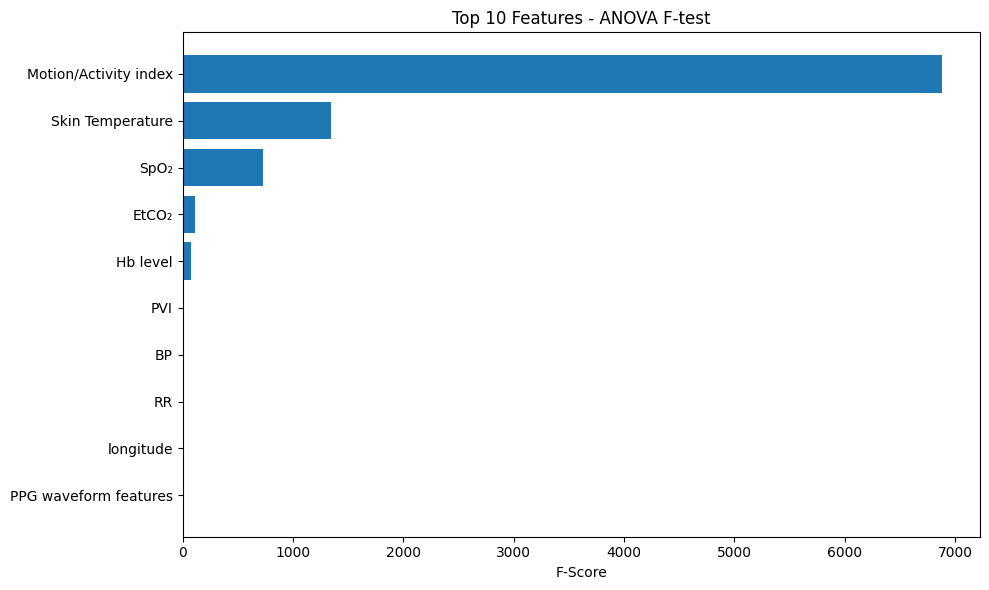

In [72]:
f_scores, p_values = f_classif(X_train, y_train)

f_test_results = pd.DataFrame({
    'Feature': X_train.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

print("Top 15 features by ANOVA F-test:")
print(f_test_results.head(15))

plt.figure(figsize=(10, 6))
plt.barh(f_test_results['Feature'].head(10), f_test_results['F_Score'].head(10))
plt.xlabel('F-Score')
plt.title('Top 10 Features - ANOVA F-test')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Тop-15 features by Mutual Information:
              Feature  MI_Score
Motion/Activity index  0.278270
     Skin Temperature  0.124748
             Hb level  0.055009
                 SpO₂  0.052997
                   CO  0.015772
   Respiratory effort  0.012271
 Signal Quality Index  0.011409
     Blood Flow Index  0.008543
PPG waveform features  0.007001
  O₂ extraction ratio  0.006869
                EtCO₂  0.006136
                   BP  0.004769
            longitude  0.003358
                  PVI  0.002416
                   HR  0.002262


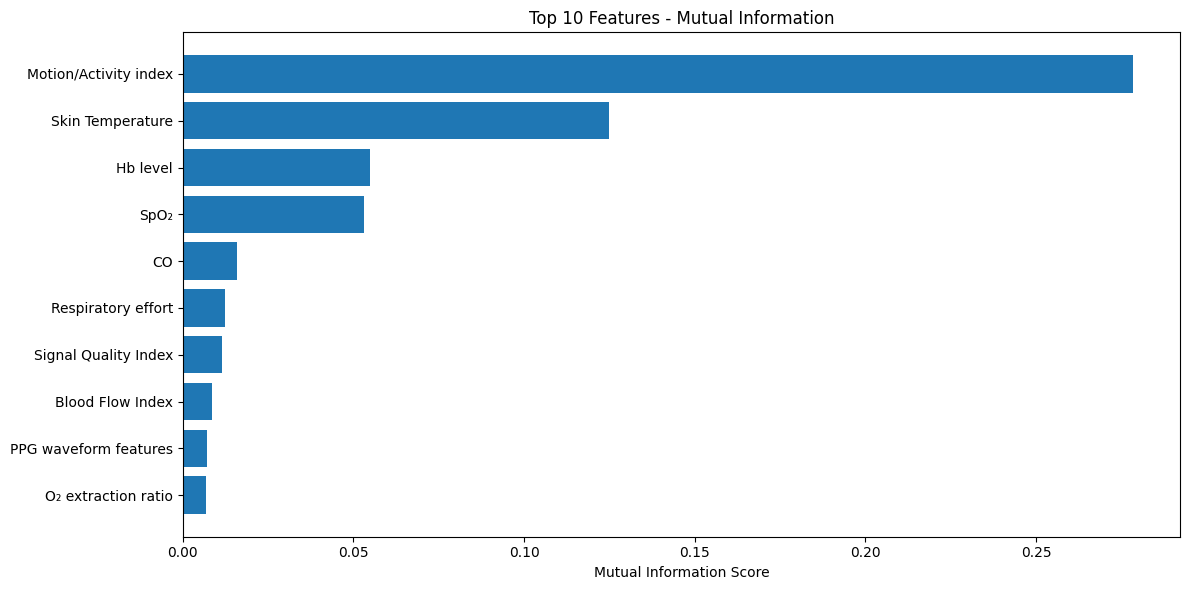

In [73]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_results = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Тop-15 features by Mutual Information:")
print(mi_results.head(15).to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(mi_results['Feature'].head(10), mi_results['MI_Score'].head(10))
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Features - Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Top-15 features за Random Forest Importance:
              Feature  RF_Importance
Motion/Activity index       0.326156
     Skin Temperature       0.153360
                 SpO₂       0.080709
             Hb level       0.070530
                  PVI       0.045240
                EtCO₂       0.042477
                 FiO₂       0.018562
                   PI       0.018453
PPG waveform features       0.018252
                  PRV       0.018082
                  SNR       0.018000
 Signal Quality Index       0.017953
                   RR       0.017924
                   SV       0.017824
     Blood Flow Index       0.017687


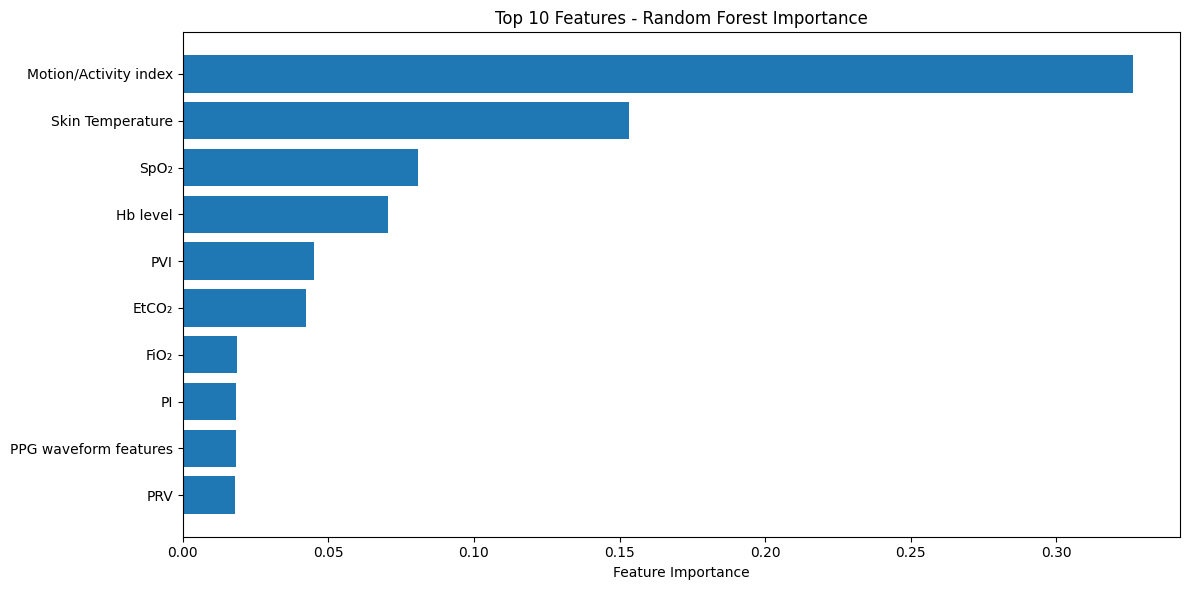

In [74]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_results = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("Top-15 features за Random Forest Importance:")
print(rf_results.head(15).to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(rf_results['Feature'].head(10), rf_results['RF_Importance'].head(10))
plt.xlabel('Feature Importance')
plt.title('Top 10 Features - Random Forest Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [75]:
print("Top 5 of each method:")
print("ANOVA F-test:", f_test_results['Feature'].head(5).tolist())
print("Mutual Information:", mi_results['Feature'].head(5).tolist())
print("Random Forest Importance:", rf_results['Feature'].head(5).tolist())

Top 5 of each method:
ANOVA F-test: ['Motion/Activity index', 'Skin Temperature', 'SpO₂', 'EtCO₂', 'Hb level']
Mutual Information: ['Motion/Activity index', 'Skin Temperature', 'Hb level', 'SpO₂', 'CO']
Random Forest Importance: ['Motion/Activity index', 'Skin Temperature', 'SpO₂', 'Hb level', 'PVI']


Correlation coeficient

Motion/Activity index - oximetry     0.663803

Skin Temperature - oximetry     0.364418

Hb level - oximetry    -0.088805

EtCO₂ - oximetry    -0.109105

# B-1b

In [76]:
comparison_df = pd.DataFrame({'Feature': X_train.columns})

comparison_df = comparison_df.merge(f_test_results[['Feature', 'F_Score']], on='Feature')

comparison_df = comparison_df.merge(mi_results[['Feature', 'MI_Score']], on='Feature')

comparison_df = comparison_df.merge(rf_results[['Feature', 'RF_Importance']], on='Feature')

comparison_df['ANOVA_Rank'] = comparison_df['F_Score'].rank(ascending=False)
comparison_df['MI_Rank'] = comparison_df['MI_Score'].rank(ascending=False)
comparison_df['RF_Rank'] = comparison_df['RF_Importance'].rank(ascending=False)

comparison_df['Average_Rank'] = comparison_df[['ANOVA_Rank', 'MI_Rank', 'RF_Rank']].mean(axis=1)

In [77]:
importance_list = comparison_df[['Feature', 'Average_Rank']].sort_values('Average_Rank')

for i, (idx, row) in enumerate(importance_list.iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:25} (Importance: {row['Average_Rank']:.1f})")

top_10 = importance_list.head(10)['Feature'].tolist()

 1. Motion/Activity index     (Importance: 1.0)
 2. Skin Temperature          (Importance: 2.0)
 3. SpO₂                      (Importance: 3.3)
 4. Hb level                  (Importance: 4.0)
 5. EtCO₂                     (Importance: 7.0)
 6. PVI                       (Importance: 8.3)
 7. PPG waveform features     (Importance: 9.3)
 8. Blood Flow Index          (Importance: 11.7)
 9. BP                        (Importance: 12.0)
10. RR                        (Importance: 12.3)
11. Signal Quality Index      (Importance: 13.0)
12. PI                        (Importance: 13.2)
13. longitude                 (Importance: 13.3)
14. CO                        (Importance: 14.0)
15. O₂ extraction ratio       (Importance: 14.3)
16. Respiratory effort        (Importance: 14.7)
17. SNR                       (Importance: 14.8)
18. FiO₂                      (Importance: 14.8)
19. SV                        (Importance: 15.7)
20. PRV                       (Importance: 16.0)
21. HR                     

# C-1b

For feature selection, three complementary techniques were implemented:<br/> 
 -**ANOVA F-test** to identify linear relationships with the target variable<br/>
 -**Mutual Information** to capture non-linear dependencies<br/>
 -**Random Forest** for model-based importance assessment

 According to the combined results of all tests, the top-7 features to keep are: Motion/Activity index (1.0), Skin Temperature (2.0), SpO₂ (3.0), Hb level (4.3), EtCO₂ (6.0), PVI (7.3), Signal Quality Index (8.7)
 
While Motion/Activity index should be removed because it represents measurement artifacts rather than physiological relationships, which could lead the model to learn technical noise instead of genuine clinical patterns for oximetry prediction.

The final feature set retains eight clinically and technically significant parameters: physiological variables including **Skin Temperature** (affecting peripheral circulation), **SpO₂** (direct oxygenation measure), **Hb level** (oxygen transport determinant), **EtCO₂** (respiratory function indicator), and **RR** (respiratory rate); technical quality metrics comprising **Signal Quality Index** and **PPG** waveform features for signal reliability assessment; and **PVI** (perfusion index) for tissue perfusion evaluation - collectively providing a balanced representation of genuine physiological relationships while excluding technical artifacts like motion interference and non-predictive geographical data.

# 2.3 Replikovateľnosť predspracovania (5b)

# (A-3b) Upravte váš kód realizujúci predspracovanie trénovacej množiny tak, aby ho bolo možné bez ďalších úprav znovu použiť na predspracovanie testovacej množiny v kontexte strojového učenia.


Som urobil funkciu predspracovanie_train(), ktorá predspracuje informaciu v datasete.
Týmto spôsobom sa predspracovanie dá znovu použiť aj na testovaciu množinu v rámci strojového učenia.

In [78]:
test_data.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
3156,97.035476,77.550782,12.075892,15.682449,39.563496,77.061007,94.071144,103.216868,35.972746,11.439856,...,4.061216,50.652476,56.344579,45.122484,55.912701,0.223797,28.728942,1.0,13.48082,-86.58208
6312,98.190986,77.584999,8.721129,17.971966,39.267283,40.680467,98.437701,97.942963,36.008220,14.374636,...,4.064137,47.124358,60.719341,38.010386,33.663664,0.275424,21.541262,1.0,48.25000,16.40000
2202,96.755378,72.859161,13.404794,16.679869,40.728649,61.608949,130.840704,104.188120,36.412111,11.345399,...,4.030303,48.480740,54.473582,48.049121,58.956965,0.255783,28.581492,1.0,57.47908,-4.22398
479,97.872542,85.701570,7.466221,16.390695,39.279033,59.482722,146.088590,103.226809,37.062102,8.169460,...,4.264570,67.874913,52.004847,55.068769,46.517031,0.260622,28.446366,1.0,38.45598,48.87498
6776,97.997891,85.615883,8.564190,16.976180,39.741041,47.913329,75.250066,100.072438,35.892862,8.593973,...,4.257397,41.143892,47.635337,38.004077,55.943713,0.297926,33.036098,1.0,19.30157,72.85107


In [79]:
test_data.shape

(2923, 23)

In [80]:
X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

In [81]:
X_train

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,SV,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude
8200,98.208748,80.323656,12.150147,15.283295,39.077906,69.498459,123.898105,102.350237,36.180164,7.387721,...,73.496548,4.103448,36.736880,36.489288,36.809471,60.852602,0.287768,28.862638,55.25000,24.75000
4552,97.380011,78.248592,10.250743,17.450963,41.571342,59.885806,69.517592,108.425766,36.275044,11.966966,...,77.138595,4.059704,38.683294,60.250658,49.979726,43.846962,0.271748,35.764563,-17.73648,168.31366
9412,96.995350,85.760481,8.998016,17.675217,38.004043,56.297085,119.491511,103.626067,35.430986,7.555965,...,70.452166,4.277675,28.686236,59.802226,77.230241,69.823809,0.246302,26.550661,41.55815,-73.05150
622,97.065277,90.041071,10.153855,17.136273,39.165934,60.082066,124.300843,111.593069,35.379090,7.152051,...,84.922665,4.591265,50.026568,44.697854,64.135994,72.256898,0.206866,23.740835,46.51872,86.00214
3930,98.553893,74.009752,9.151582,16.053110,39.920258,55.313066,106.625515,106.026883,34.127712,3.849298,...,90.539007,4.037799,35.791613,41.743906,69.190474,54.604334,0.267024,38.561122,56.85836,35.90057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11608,97.237024,70.198641,11.155333,17.034568,39.920891,59.502204,106.106378,104.290158,36.159286,6.508573,...,71.234112,4.028819,46.014116,50.460412,28.700984,46.544569,0.269834,20.851546,41.47892,-87.45476
5335,97.282041,83.218833,7.535263,15.945863,39.793835,60.325892,111.929991,106.201905,34.537272,4.257175,...,69.295709,4.163696,50.523161,43.222120,51.636748,82.410804,0.277063,27.124843,18.51957,73.85535
5543,97.582904,93.500103,10.250121,16.035905,40.678798,51.709876,140.047055,102.449591,35.973161,9.097211,...,84.669000,5.150840,34.973247,53.673183,50.552733,34.511696,0.213165,26.228306,34.56861,105.89333
883,98.108307,75.995419,9.712895,17.777120,38.279059,70.838656,156.361455,97.459673,34.381280,13.830447,...,73.639546,4.053109,17.686776,45.631710,59.302913,69.357932,0.233645,21.971878,53.43333,-7.95000


# (B-2b) Využite možnosti sklearn.pipeline

In [82]:
cols = list(X_train.columns)
minmax_cols = cols[:-2]
standard_cols = ['latitude', 'longitude']

feature_names = cols

#custom_preprocessor = FunctionTransformer(predspracovanie_train, feature_names_out=None)

preprocessor = ColumnTransformer(transformers=[
    ('minmax', MinMaxScaler(), minmax_cols),
    ('standard', StandardScaler(), standard_cols)
])

pipeline = Pipeline([
    # тут проблемма в том что при удалении из х трейн мы не удаляем из й трейн
    #('custom_cleaning', custom_preprocessor),
    ('preprocessor', preprocessor)
])

pipeline.fit(X_train, y_train)

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [83]:
X_train_transformed.shape

(8766, 22)

In [84]:
y_train.shape

(8766,)

In [85]:
X_train_transformed

array([[ 0.6188945 ,  0.50809139,  0.60354279, ...,  0.44313191,
         1.11093075,  0.19516636],
       [ 0.44257304,  0.4562148 ,  0.50761327, ...,  0.78822813,
        -1.92576546,  2.12390495],
       [ 0.36073269,  0.64401201,  0.44434423, ...,  0.32753305,
         0.54126375, -1.11877009],
       ...,
       [ 0.48574036,  0.83750257,  0.50758185, ...,  0.31141528,
         0.25045496,  1.28530485],
       [ 0.5975248 ,  0.39988548,  0.48044926, ...,  0.09859388,
         1.03534586, -0.24414921],
       [ 0.58223391,  0.53165138,  0.26058361, ...,  0.66667937,
        -0.38474984,  0.84139111]], shape=(8766, 22))

In [86]:
X_test_transformed

array([[ 0.36926981,  0.43876956,  0.59979253, ...,  0.43644709,
        -0.62692961, -1.30054974],
       [ 0.61511532,  0.43962498,  0.43036007, ...,  0.07706312,
         0.81968676,  0.08298639],
       [ 0.30967655,  0.32147903,  0.6669088 , ...,  0.42907462,
         1.20367448, -0.19409115],
       ...,
       [ 0.44231891,  0.57869454,  0.48120409, ...,  0.03756637,
         0.27059449, -1.19705237],
       [ 0.34797973,  0.40062746,  0.31863743, ...,  0.48537349,
        -0.62335771, -0.34692487],
       [ 0.18158571,  0.68786693,  0.3634915 , ...,  0.88685084,
        -1.54840437, -0.61718684]], shape=(2923, 22))

In [87]:
y_train = y_train.values
y_test = y_test.values

Implementoval som dátový spracovateľský reťazec (Pipeline), ktorý spája všetky kroky predspracovania do jednej postupnosti.

V prvom kroku sa používa vlastný predspracovateľ — funkcia predspracovanie_train, zabalená do FunctionTransformer.
Táto funkcia čistí dáta odstránením odľahlých hodnôt (outliers) v kľúčových atribútoch, ako sú Blood Flow Index, PPG waveform features a ďalšie, na základe medzikvartilového rozpätia (IQR).

Následne sa používa ColumnTransformer, ktorý škáluje dáta rôznymi spôsobmi podľa typu atribútu:
pre väčšinu numerických atribútov sa používa MinMaxScaler, ktorý normalizuje hodnoty do intervalu [0,1], aby mali všetky atribúty porovnateľný rozsah;
a pre súradnice latitude a longitude som použil StandardScaler, pretože môžu nadobúdať kladné aj záporné hodnoty a je dôležité zachovať ich rozdelenie okolo priemeru (normalizácia s nulovým priemerom a jednotkovou odchýlkou).

Výsledkom je, že celý proces — od čistenia až po škálovanie — sa vykonáva automaticky pomocou pipeline, čo robí kód prehľadnejším, reprodukovateľným a pripraveným na použitie pre tréningové aj testovacie dáta.

Všetky dáta sú teraz transformované do numerickej (numpy) podoby a plne pripravené na použitie v modeloch strojového učenia.

Vďaka použitiu Pipeline je zabezpečené, že rovnaké kroky predspracovania sa automaticky aplikujú aj na testovaciu množinu, čím sa eliminuje riziko chýb alebo nezhôd medzi tréningovými a testovacími dátami.

Dáta majú jednotný rozsah a vhodnú štatistickú štruktúru, čo umožňuje efektívne trénovanie modelov.

In [88]:
np.savetxt("y_train.csv", y_train, delimiter=",")
np.savetxt("y_test.csv", y_test, delimiter=",")
np.savetxt("x_train.csv", X_train_transformed, delimiter=",")
np.savetxt("x_test.csv", X_test_transformed, delimiter=",")